# PyTorch DNN model

In this notebook, we build a fully connected deep neural network (DNN) classifier for the CIFAR-10 dataset using PyTorch's `nn.Sequential` module.

## Notebook setup

### Imports

In [1]:
# Standard library imports
import pickle

# Third party imports
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets

# Package imports
from image_classification_tools.pytorch import DataPipeline
import image_classification_tools.pytorch.evaluation as eval_utils
import image_classification_tools.pytorch.plotting as plots
import image_classification_tools.pytorch.training as training

# Local imports
import configuration as config

Using device: cuda


### Hyperparameters

In [ ]:
preload_device = 'gpu' if torch.cuda.is_available() else 'cpu'
learning_rate = 1e-3
epochs = 500
early_stopping_patience = 10
print_every = 10

## 1. Load and prepare CIFAR-10 data

CIFAR-10 contains 32x32 color images (3 channels) across 10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck.

### 1.1. Visualize sample images

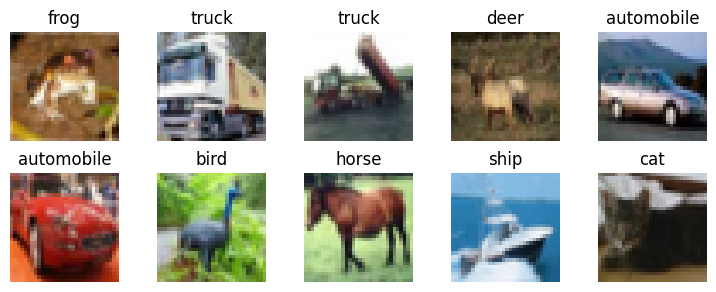

In [3]:
# Get a sample dataset for visualization
sample_dataset = datasets.CIFAR10(root=config.DATA_DIR, transform=config.RGB_TRANSFORM)

# Plot first 10 images from the training dataset
fig, axes = plots.plot_sample_images(sample_dataset, config.CLASS_NAMES)
plt.show()

### 1.2. Create data pipeline with grayscale preprocessing

In [ ]:
# Create data pipeline with grayscale preprocessing
loaders = DataPipeline(
    data_source=datasets.CIFAR10,
    split=config.SPLIT,
    train_transform=config.GRAYSCALE_TRANSFORM,
    eval_transform=config.GRAYSCALE_TRANSFORM,
    preload=preload_device,
    batch_size=config.BATCH_SIZE,
    val_size=config.VAL_SIZE,
    seed=config.SEED,
    root=config.DATA_DIR
).get_loaders()

# Display pipeline summary
print(f'\nBatch sizes: {loaders.get_batch_sizes()}')
print(f'Total samples: {loaders.total_samples()}')

memory_estimate = loaders.memory_estimate()

if memory_estimate is not None:
    print(f'Memory estimate: {memory_estimate:.2f} GB')

else:
    print('Memory estimate: N/A')

Loading train dataset...
Loading test dataset...
Creating splits...
Preloading train to GPU...


Preloading train: 100%|██████████| 40000/40000 [00:15<00:00, 2612.56it/s]


Preloading val to GPU...


Preloading val: 100%|██████████| 10000/10000 [00:03<00:00, 2687.74it/s]


Preloading test to GPU...


Preloading test: 100%|██████████| 10000/10000 [00:03<00:00, 2691.72it/s]



Batch sizes: {'train': 128, 'val': 128, 'test': 128}
Total samples: {'train': 40000, 'val': 10000, 'test': 10000}
Memory estimate: 0.69 GB


In [5]:
# Unpack loaders for convenience
train_loader = loaders.train
val_loader = loaders.val
test_loader = loaders.test

## 2. Build DNN classifier with nn.Sequential

We build a fully connected deep neural network using `nn.Sequential`. Since we are not using convolutional layers, we flatten the 32x32x1 grayscale images into a 1024-dimensional vector.

### 2.1. Define model architecture

In [6]:
# Input size: 1 x 32 x 32 = 1024 (grayscale)
model = nn.Sequential(
    nn.Flatten(),
    nn.Dropout(0.5),
    nn.Linear(1024, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 64),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(64, len(config.CLASS_NAMES))
).to(config.DEVICE)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f'\nTotal parameters: {trainable_params}')

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Dropout(p=0.5, inplace=False)
  (2): Linear(in_features=1024, out_features=1024, bias=True)
  (3): ReLU()
  (4): Dropout(p=0.5, inplace=False)
  (5): Linear(in_features=1024, out_features=256, bias=True)
  (6): ReLU()
  (7): Dropout(p=0.5, inplace=False)
  (8): Linear(in_features=256, out_features=64, bias=True)
  (9): ReLU()
  (10): Dropout(p=0.5, inplace=False)
  (11): Linear(in_features=64, out_features=10, bias=True)
)

Total parameters: 1329098


### 2.2. Define loss function and optimizer

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

### 2.3. Train model

In [ ]:
%%time

history = training.train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=config.DEVICE,
    epochs=epochs,
    print_every=print_every,
    enable_early_stopping=True,
    early_stopping_patience=early_stopping_patience
)

print()

Epoch   1/500 - loss: 2.1086 - acc: 23.49% - val_loss: 1.9408 - val_acc: 31.08%
Epoch  25/500 - loss: 1.6897 - acc: 40.82% - val_loss: 1.5887 - val_acc: 43.50%
Epoch  50/500 - loss: 1.6004 - acc: 43.92% - val_loss: 1.5230 - val_acc: 45.80%
Epoch  75/500 - loss: 1.5452 - acc: 45.90% - val_loss: 1.4890 - val_acc: 47.26%
Epoch 100/500 - loss: 1.5123 - acc: 47.32% - val_loss: 1.4755 - val_acc: 47.45%

Early stopping at epoch 107
Best val_loss: 1.4665 at epoch 97
Restored best model weights

CPU times: user 3min 53s, sys: 829 ms, total: 3min 54s
Wall time: 3min 48s


### 2.5. Learning curves

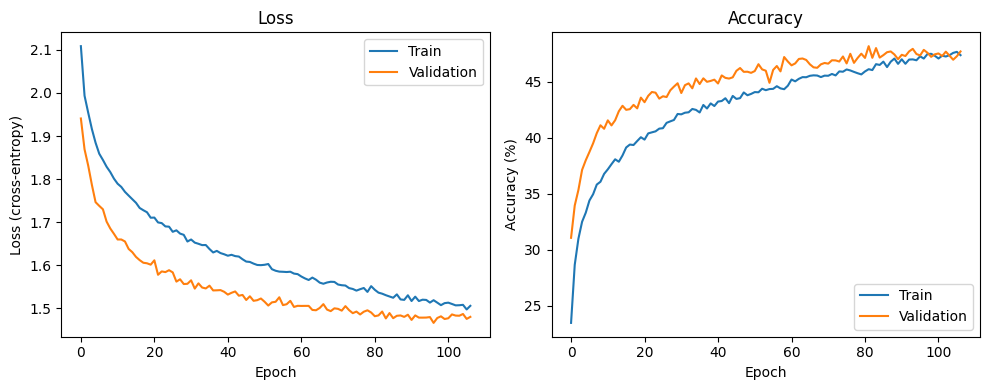

In [9]:
fig, axes = plots.plot_learning_curves(history)
plt.show()

## 3. Evaluate model on test set

### 3.1. Calculate test accuracy

In [10]:
test_accuracy, predictions, true_labels = eval_utils.evaluate_model(model, test_loader)
print(f'Test accuracy: {test_accuracy:.2f}%')

Test accuracy: 48.77%


### 3.2. Per-class accuracy

In [11]:
# Calculate per-class accuracy
class_correct = {name: 0 for name in config.CLASS_NAMES}
class_total = {name: 0 for name in config.CLASS_NAMES}

for pred, true in zip(predictions, true_labels):

    class_name = config.CLASS_NAMES[true]
    class_total[class_name] += 1

    if pred == true:
        class_correct[class_name] += 1

print('Per-class accuracy:')
print('-' * 30)

for name in config.CLASS_NAMES:
    acc = 100 * class_correct[name] / class_total[name]
    print(f'{name:12s}: {acc:.2f}%')

Per-class accuracy:
------------------------------
airplane    : 44.50%
automobile  : 56.70%
bird        : 36.20%
cat         : 23.40%
deer        : 46.60%
dog         : 46.30%
frog        : 57.40%
horse       : 55.40%
ship        : 69.10%
truck       : 52.10%


### 3.4. Confusion matrix

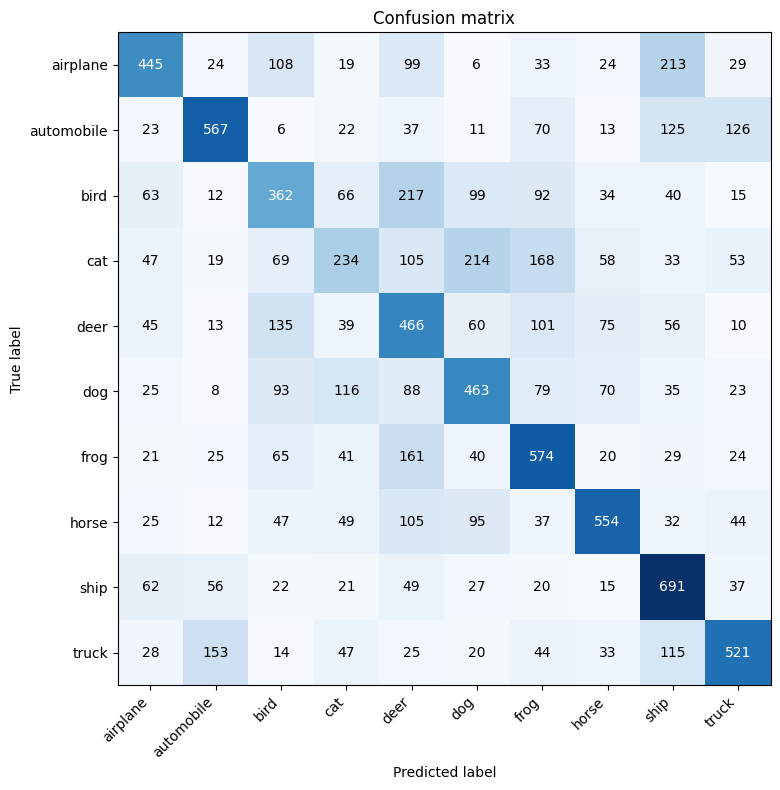

In [12]:
fig, ax = plots.plot_confusion_matrix(true_labels, predictions, config.CLASS_NAMES)
plt.show()

### 3.5. Predicted class probability distributions

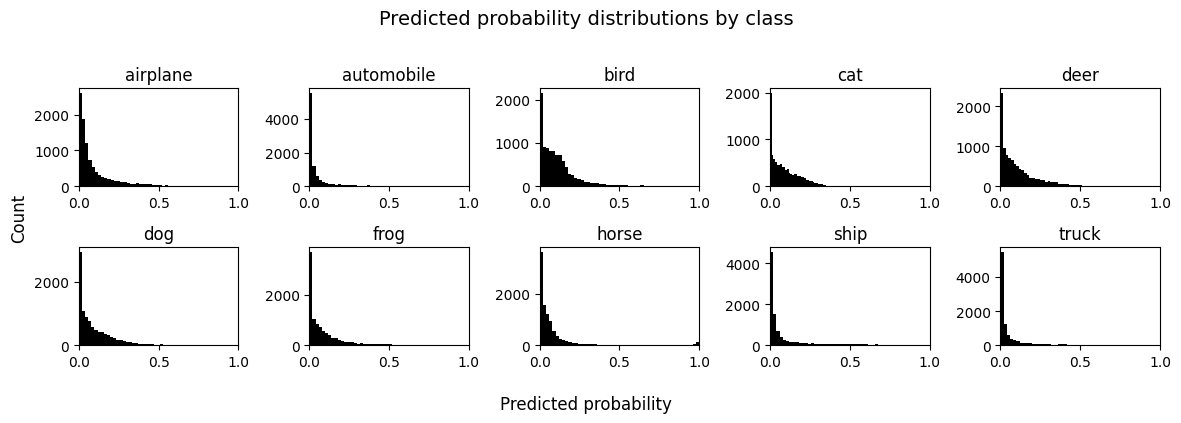

In [13]:
# Get predicted probabilities for all test samples
model.eval()
all_probs = []

with torch.no_grad():
    for images, _ in test_loader:

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())

all_probs = np.concatenate(all_probs, axis=0)

# Plot probability distributions
fig, axes = plots.plot_class_probability_distributions(all_probs, config.CLASS_NAMES)
plt.show()

### 3.6. Evaluation curves

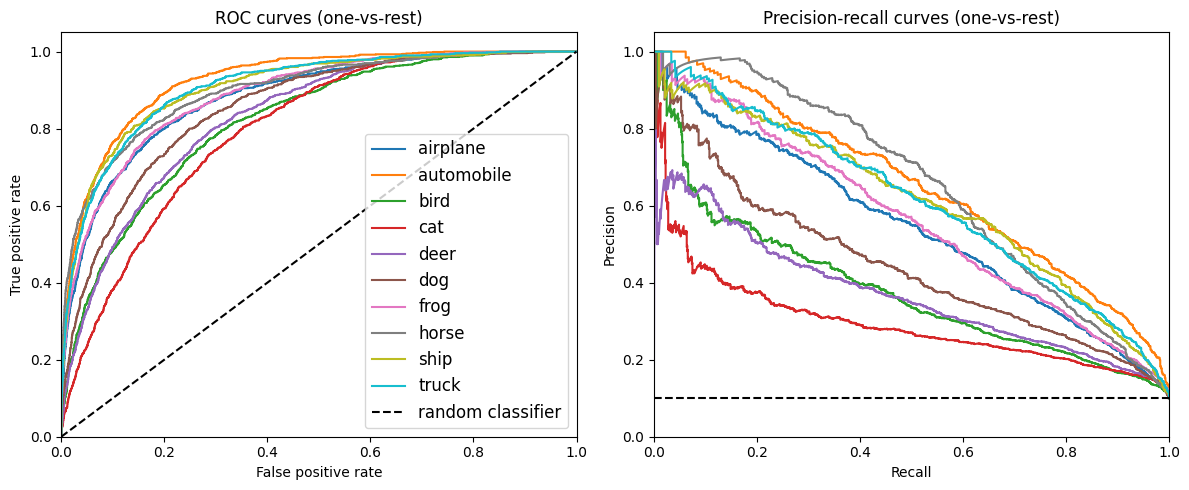

In [14]:
fig, (ax1, ax2) = plots.plot_evaluation_curves(true_labels, all_probs, config.CLASS_NAMES)
plt.show()

## 4. Save model

In [15]:
# Save trained model
model_path = config.MODELS_DIR / 'dnn.pth'
torch.save(model, model_path)

print(f'Model saved to: {model_path}')
print(f'Test accuracy: {test_accuracy:.2f}%')

Model saved to: ../models/pytorch/dnn.pth
Test accuracy: 48.77%


## 5. Save test results for comparison

In [ ]:
# Save performance results
results_path = config.RESULTS_DIR / 'dnn_results.pkl'

# Count model parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# Create results dictionary
results_dict = {
    'true_labels': true_labels,
    'predictions': predictions,
    'all_probs': all_probs,
    'test_accuracy': test_accuracy,
    'total_params': total_params,
    'trainable_params': trainable_params
}

# Save results
with open(results_path, 'wb') as f:
    pickle.dump(results_dict, f)

print(f'Test results saved to: {results_path}')
print(f'  - Test accuracy: {test_accuracy:.2f}%')
print(f'  - Trainable parameters: {trainable_params:,}')
print(f'  - Total parameters: {total_params:,}')

Test results saved to: ../data/pytorch/performance_results/dnn_results.pkl
  - Test accuracy: 48.77%
  - Trainable parameters: 1,329,098
  - Total parameters: 1,329,098
